# 05 — Fibrotic-score × spatial-ring interactions

This notebook tests whether associations between continuous fibrotic NMF intensity and molecular readouts change across spatial rings.

For each of 10 genes and 14 pathways, the interaction model is:

`outcome ~ fibrotic_score * ring + sample`

Unlike Notebook 04, this model explicitly allows the fibrotic-score slope to differ across rings. Cell-type-composition interactions are not analyzed here. Results are associations, not causal effects.

In [10]:
from collections import deque
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import sparse
from statsmodels.stats.multitest import multipletests

sc.set_figure_params(dpi=100, facecolor="white")
sns.set_theme(style="whitegrid")
adata=sc.read_h5ad("../data/adata_vis_human_spatial_paper.h5ad")

In [11]:
genes=["COL1A1","COL3A1","CTHRC1","POSTN","KRT7","SPP1","SFTPC","AGER","MUC5B","SCGB1A1"]
pathways=["Androgen","EGFR","Estrogen","Hypoxia","JAK-STAT","MAPK","NFkB","PI3K","TGFb","TNFa","Trail","VEGF","WNT","p53"]
heatmap_pathways=["TGFb","MAPK","EGFR","TNFa","Hypoxia","NFkB"]
pathway_display_names = {
    "TGFb": "TGF-β signaling pathway",
    "MAPK": "MAPK signaling pathway",
    "EGFR": "EGFR signaling pathway",
    "TNFa": "TNF-α signaling pathway",
    "Hypoxia": "Hypoxia signaling pathway",
    "NFkB": "NF-κB signaling pathway",
}
assert not set(genes)-set(adata.var_names)
assert not set(pathways)-set(adata.obsm["mlm_estimate"].columns)

## Reconstruct predictors and rings

Factor 6 is converted to the same relative fibrotic score used in Notebooks 02 and 04. Ring distance is recalculated on the native six-neighbor Visium lattice. The interaction analysis uses Fibrotic through Ring 4; the heterogeneous pooled `5+` group is excluded because it is not one discrete distance.

In [12]:
factor_columns=sorted([c for c in adata.obs if c.startswith("mean_nUMI_factorsfact_")],key=lambda c:int(c.rsplit("_",1)[-1]))
adata.obs["fibrotic_score"]=(adata.obs["mean_nUMI_factorsfact_6"]/adata.obs[factor_columns].sum(axis=1).replace(0,np.nan)).fillna(0)
overview=adata.obs.groupby("sample",observed=True).agg(treatment=("treatment","first"),fibrotic_spots=("Niche_NMF",lambda x:(x=="Fibrotic").sum()))
ipf_samples=overview.index[overview.treatment.astype(str).eq("IPF") & overview.fibrotic_spots.gt(0)].tolist()

def lattice_distance(obs):
    xy=obs[["array_row","array_col"]].astype(int).to_numpy(); lookup={tuple(v):i for i,v in enumerate(xy)}
    d=np.full(len(obs),np.inf); start=np.flatnonzero(obs.Niche_NMF.astype(str).eq("Fibrotic").to_numpy()); d[start]=0; q=deque(start.tolist())
    for_current=((-1,-1),(-1,1),(0,-2),(0,2),(1,-1),(1,1))
    while q:
        i=q.popleft(); r,c=xy[i]
        for dr,dc in for_current:
            j=lookup.get((r+dr,c+dc))
            if j is not None and np.isinf(d[j]): d[j]=d[i]+1; q.append(j)
    return d

distance=pd.Series(np.nan,index=adata.obs_names)
for sample in ipf_samples:
    mask=adata.obs["sample"].eq(sample); distance.loc[mask]=lattice_distance(adata.obs.loc[mask])
adata.obs["ring_distance"]=distance.replace(np.inf,np.nan)
ring_order=["Fibrotic","Ring 1","Ring 2","Ring 3","Ring 4"]
labels={0:"Fibrotic",1:"Ring 1",2:"Ring 2",3:"Ring 3",4:"Ring 4"}
adata.obs["interaction_ring"]=adata.obs["ring_distance"].map(labels)
mask=adata.obs["sample"].isin(ipf_samples)&adata.obs["interaction_ring"].notna()

In [13]:
base=adata.obs.loc[mask,["sample","interaction_ring","fibrotic_score"]].copy()
base["sample"]=base["sample"].astype(str)
base["ring"]=pd.Categorical(base.pop("interaction_ring"),categories=ring_order,ordered=True)
def z(x):
    x=np.asarray(x,float); return (x-np.nanmean(x))/np.nanstd(x)
base["fibrotic_score_z"]=z(base.fibrotic_score)
X=adata[mask,genes].X
if sparse.issparse(X): X=X.toarray()
outcomes={"Gene":pd.DataFrame(X,index=base.index,columns=genes),"Pathway":adata.obsm["mlm_estimate"].loc[base.index,pathways].copy()}
print(f"Interaction spots: {len(base):,}; IPF sections: {base['sample'].nunique()}")
print(base.ring.value_counts(sort=False))

Interaction spots: 18,395; IPF sections: 5
ring
Fibrotic    2817
Ring 1      4301
Ring 2      4252
Ring 3      3794
Ring 4      3231
Name: count, dtype: int64


## Modeling strategy

For each gene or pathway, a joint HC3-robust Wald test evaluates whether all fibrotic-score-by-ring interaction coefficients equal zero. This is the primary interaction test. Ring-specific slopes and 95% confidence intervals are then reconstructed for interpretation. BH-FDR correction is applied across the 24 tested molecular outcomes.

In [14]:
def interaction_models(predictor, family):
    tests=[]; slopes=[]
    for kind,frame in outcomes.items():
        for feature in frame.columns:
            data=base[["sample","ring",predictor]].copy(); data["outcome_z"]=z(frame[feature]); data=data.dropna()
            fit=smf.ols(f"outcome_z ~ {predictor} * C(ring) + C(sample)",data=data).fit(cov_type="HC3")
            terms=[n for n in fit.params.index if f"{predictor}:C(ring)" in n]
            R=np.zeros((len(terms),len(fit.params)))
            for row,term in enumerate(terms): R[row,fit.params.index.get_loc(term)]=1
            test=fit.wald_test(R,scalar=True)
            tests.append({"family":family,"outcome_type":kind,"feature":feature,"interaction_p":float(test.pvalue),"n_spots":int(fit.nobs)})
            for ring in ring_order:
                weights=np.zeros(len(fit.params)); weights[fit.params.index.get_loc(predictor)]=1
                term=f"{predictor}:C(ring)[T.{ring}]"
                if term in fit.params.index: weights[fit.params.index.get_loc(term)]=1
                estimate=float(weights@fit.params); se=float(np.sqrt(weights@fit.cov_params()@weights))
                slopes.append({"family":family,"outcome_type":kind,"feature":feature,"ring":ring,"slope":estimate,"ci_low":estimate-1.96*se,"ci_high":estimate+1.96*se})
    tests=pd.DataFrame(tests); tests["interaction_fdr"]=multipletests(tests.interaction_p,method="fdr_bh")[1]
    return tests,pd.DataFrame(slopes)

fibrotic_tests,fibrotic_slopes=interaction_models("fibrotic_score_z","Fibrotic score")
fibrotic_tests.sort_values("interaction_fdr").head(15)

,family,outcome_type,feature,interaction_p,n_spots,interaction_fdr
1,Fibrotic score,Gene,COL3A1,5.402566e-205,18395,1.296616e-203
0,Fibrotic score,Gene,COL1A1,1.552947e-195,18395,1.863537e-194
4,Fibrotic score,Gene,KRT7,6.172768e-98,18395,4.938214e-97
15,Fibrotic score,Pathway,MAPK,1.049775e-80,18395,6.298652e-80
6,Fibrotic score,Gene,SFTPC,1.109877e-68,18395,5.327409e-68
11,Fibrotic score,Pathway,EGFR,3.058343e-48,18395,1.223337e-47
12,Fibrotic score,Pathway,Estrogen,1.712278e-46,18395,5.870666e-46
19,Fibrotic score,Pathway,TNFa,8.076439e-24,18395,2.422932e-23
16,Fibrotic score,Pathway,NFkB,1.531840e-12,18395,4.084908e-12
9,Fibrotic score,Gene,SCGB1A1,2.036761e-12,18395,4.888227e-12


## Fibrotic-score × ring interactions

The forest plot shows the adjusted fibrotic-score slope within each spatial ring. Differences among slopes—not whether an individual slope crosses zero—determine the formal interaction result.

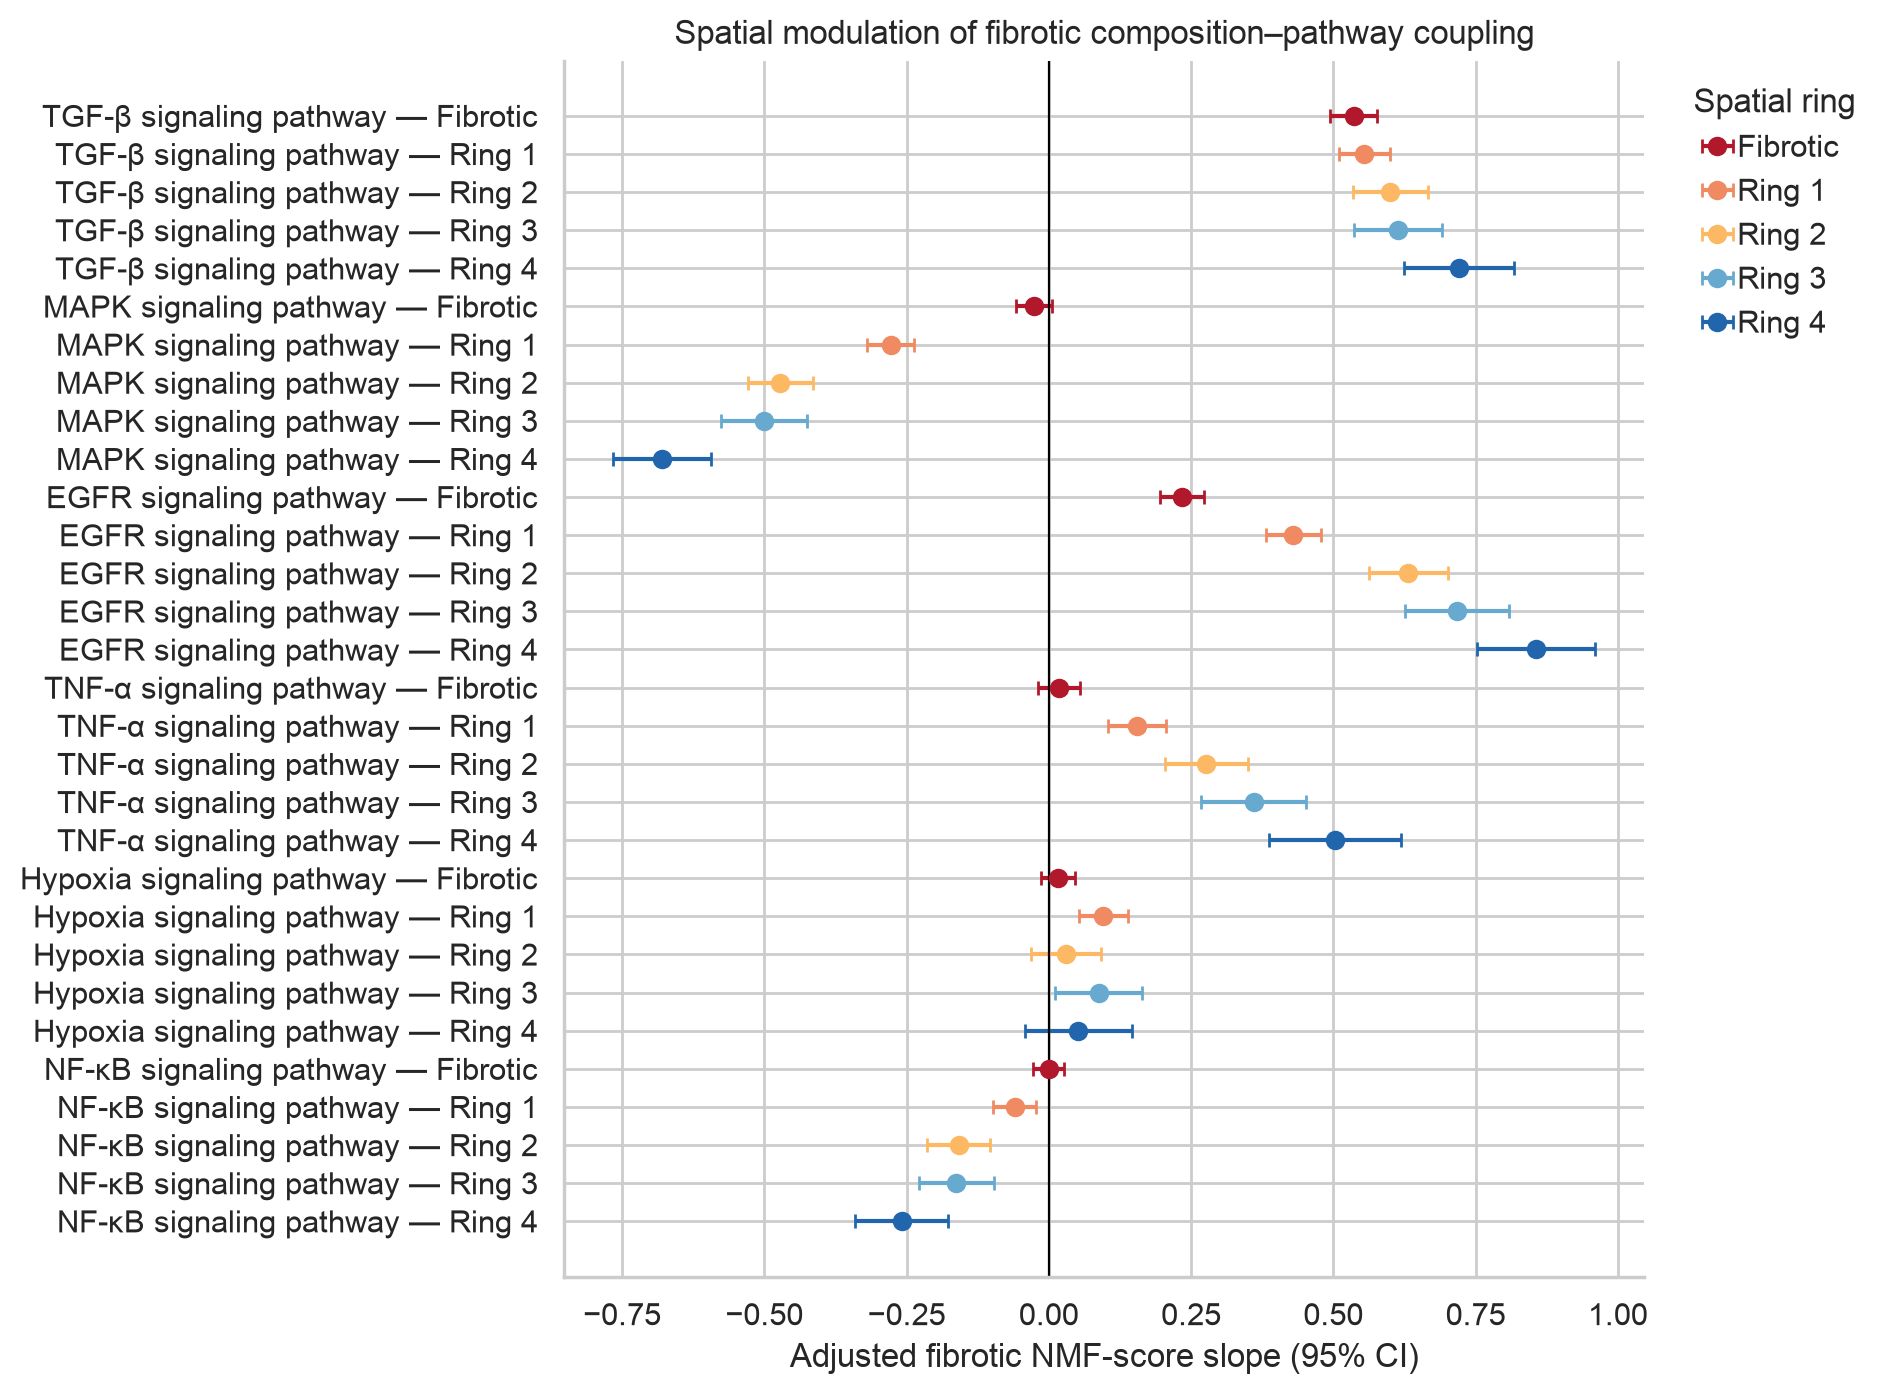

In [15]:
selected_pathways=["TGFb","MAPK","EGFR","TNFa","Hypoxia","NFkB"]
plot=fibrotic_slopes.query("outcome_type == 'Pathway' and feature in @selected_pathways").copy()
plot["display_name"]=plot["feature"].map(pathway_display_names)
plot["label"]=plot.display_name+" — "+plot.ring
plot["label"]=pd.Categorical(
    plot.label,
    categories=[f"{pathway_display_names[p]} — {r}" for p in selected_pathways for r in ring_order][::-1],
    ordered=True,
)
plot=plot.sort_values("label")

ring_palette={
    "Fibrotic":"#B2182B",
    "Ring 1":"#EF8A62",
    "Ring 2":"#FDB863",
    "Ring 3":"#67A9CF",
    "Ring 4":"#2166AC",
}

fig,ax=plt.subplots(figsize=(9,8))
y=np.arange(len(plot))
for ring in ring_order:
    ring_mask=plot["ring"].eq(ring).to_numpy()
    ring_data=plot.loc[ring_mask]
    ax.errorbar(
        ring_data.slope,
        y[ring_mask],
        xerr=[
            ring_data.slope-ring_data.ci_low,
            ring_data.ci_high-ring_data.slope,
        ],
        fmt="o",
        color=ring_palette[ring],
        ecolor=ring_palette[ring],
        capsize=2.5,
        markersize=6,
        label=ring,
    )

ax.axvline(0,color="black",lw=.8)
ax.set_yticks(y,plot.label.astype(str))
ax.set_xlabel("Adjusted fibrotic NMF-score slope (95% CI)")
ax.set_title("Spatial modulation of fibrotic composition–pathway coupling")
ax.legend(title="Spatial ring", frameon=False, bbox_to_anchor=(1.02,1), loc="upper left")
sns.despine(ax=ax)
fig.subplots_adjust(right=0.78)
plt.show()

### Main biological findings

**TGF-β signaling pathway** shows the clearest composition-dominated pattern. Its adjusted slopes are consistently positive—approximately 0.55–0.75—from the Fibrotic core through Ring 4, with relatively small differences among rings. Thus, TGF-β activity remains tightly coupled to the local fibrotic compositional state across the peri-fibrotic neighborhood, with comparatively little spatial modulation.

**MAPK signaling pathway** behaves very differently. Its association with fibrotic score is negative in every ring, but the inverse coupling is weaker in the Fibrotic core (approximately −0.20) and becomes substantially stronger in Ring 1 and the more distant rings (approximately −0.49 to −0.70). This supports the interpretation that MAPK signaling shows strong spatial modulation of its inverse association with the fibrotic compositional state.

**EGFR signaling pathway** shows a clear outward-strengthening pattern. The adjusted slope is approximately +0.32 in the Fibrotic core and increases toward approximately +0.5–0.7 in Ring 1–4. The same degree of fibrotic-like composition is therefore associated with stronger EGFR activity in the surrounding tissue context, consistent with a transition-zone or peri-fibrotic signaling program.

**TNF-α signaling pathway** shows a related but more step-like change. Its adjusted slope is relatively modest in the Fibrotic core (approximately +0.13) and increases to approximately +0.35–0.60 in Ring 1–4. This indicates stronger coupling between TNF-α signaling and fibrotic-like composition in surrounding peri-fibrotic tissue than within the hard Fibrotic niche itself.


**Hypoxia signaling pathway** shows comparatively small adjusted slopes centered near zero to modestly positive values across rings. Its coupling with fibrotic composition is therefore much weaker than that of TGF-β, and the ring-to-ring changes do not support the same strong monotonic outward pattern seen for EGFR. This suggests that hypoxia-associated transcriptional activity may reflect additional local tissue conditions beyond fibrotic composition alone.

**NF-κB signaling pathway** is close to uncoupled from fibrotic score in the Fibrotic core, but its adjusted slope becomes progressively more negative in the outer rings. This pattern suggests that the relationship between inflammatory NF-κB activity and fibrotic-like composition depends on spatial context, with stronger inverse coupling in surrounding tissue. The effect should be interpreted using its confidence intervals and joint interaction FDR rather than slope direction alone.

| Signaling pathway | Fibrotic-score association | Spatial modulation |
|---|---|---|
| TGF-β signaling pathway | Consistently strong positive | Minimal |
| MAPK signaling pathway | Negative | Markedly stronger outside the core |
| EGFR signaling pathway | Positive | Strengthens outward |
| TNF-α signaling pathway | Positive | Much stronger outside the core |
| Hypoxia signaling pathway | Weak to modest positive | Limited/non-monotonic variation across rings |
| NF-κB signaling pathway | Near zero to negative | Increasingly negative toward outer rings |

Together, these results support a concise biological model: **TGF-β signaling most directly tracks the fibrotic cellular state; MAPK, EGFR, TNF-α, and NF-κB signaling are more strongly shaped by spatial context; and Hypoxia signaling shows a weaker, less monotonic relationship with fibrotic composition across rings.**

### Statistical caveat

The narrow 95% confidence intervals partly reflect the large number of Visium spots treated as observations. Including `C(sample)` controls section-level intercept differences, but it does not eliminate spatial autocorrelation or pseudoreplication among spots from the same section. These results should therefore be described as **sample-adjusted associations from an exploratory spatial analysis**, rather than interpreted primarily through extremely small p-values or as causal effects. A publication-level extension should use section/donor-aware uncertainty estimation and explicitly account for spatial dependence.

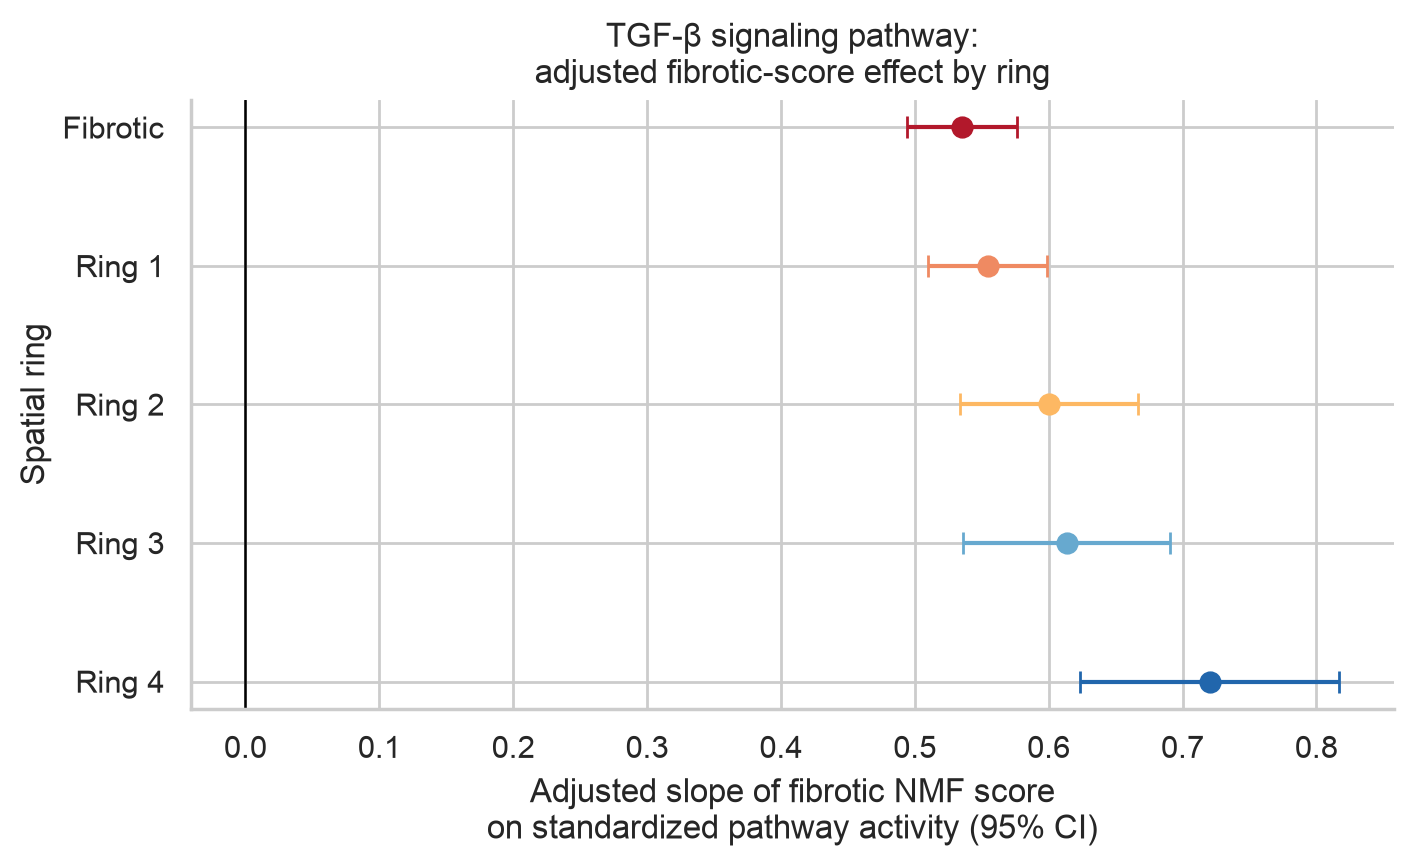

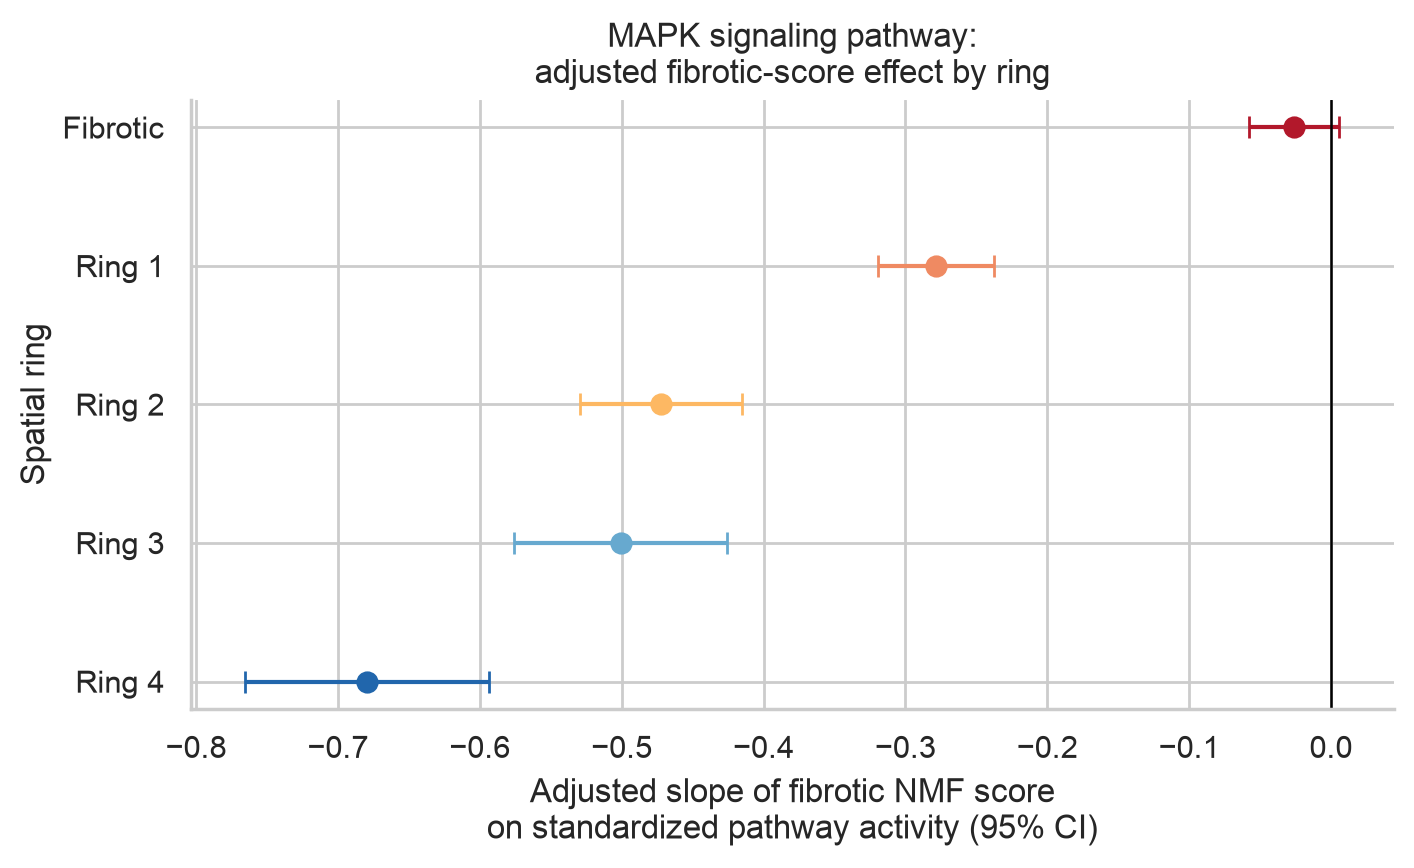

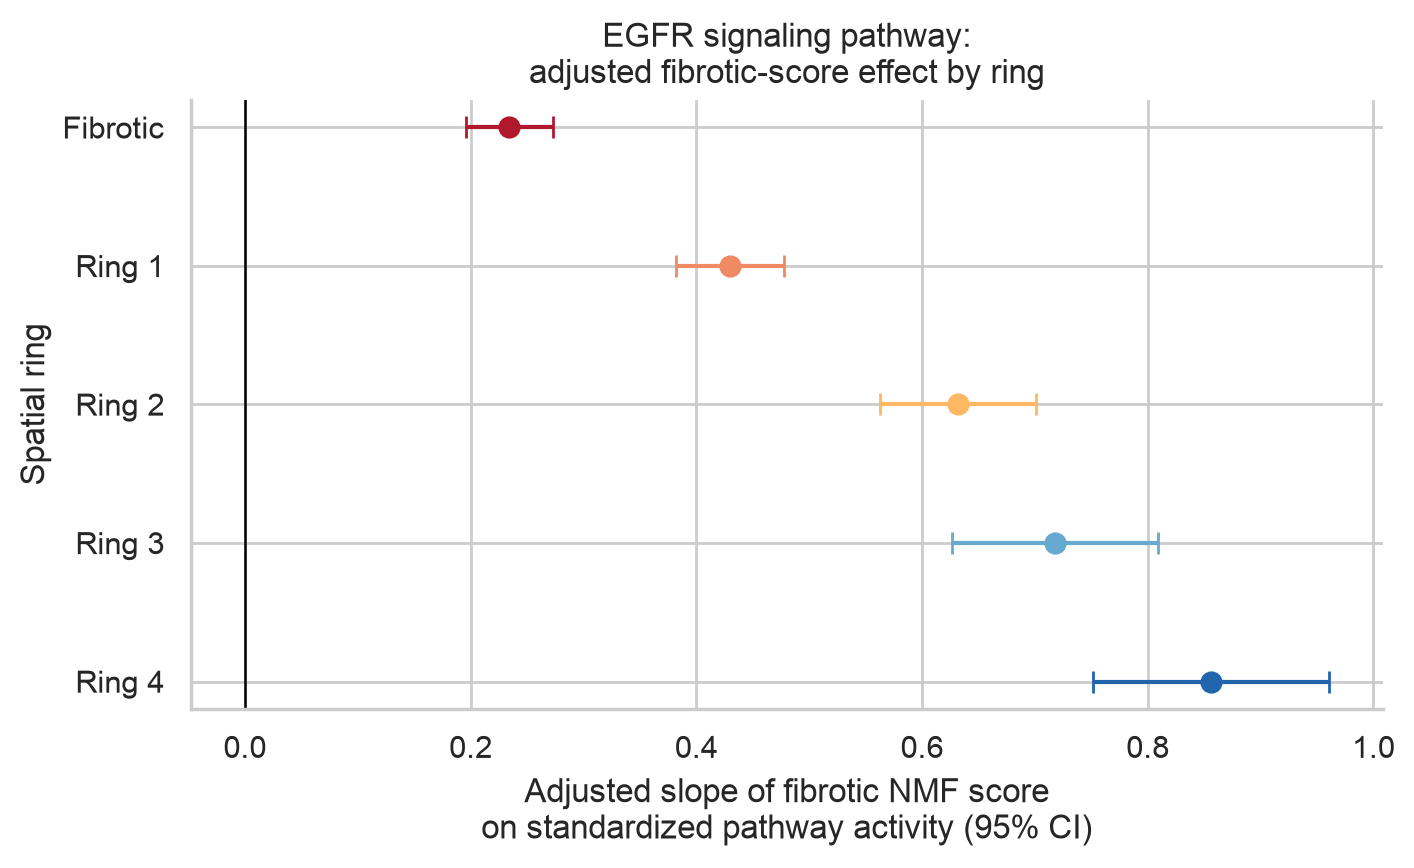

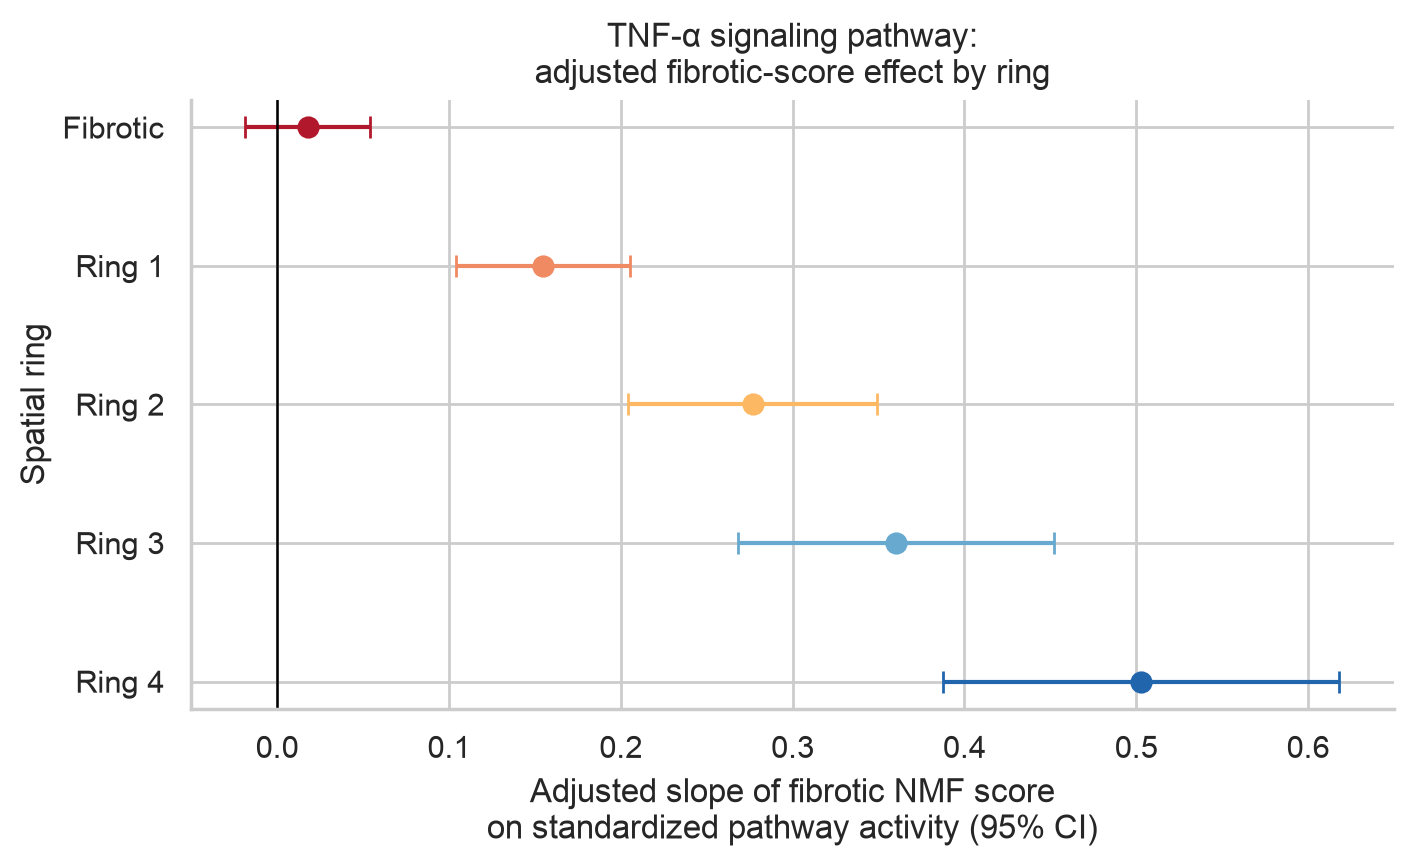

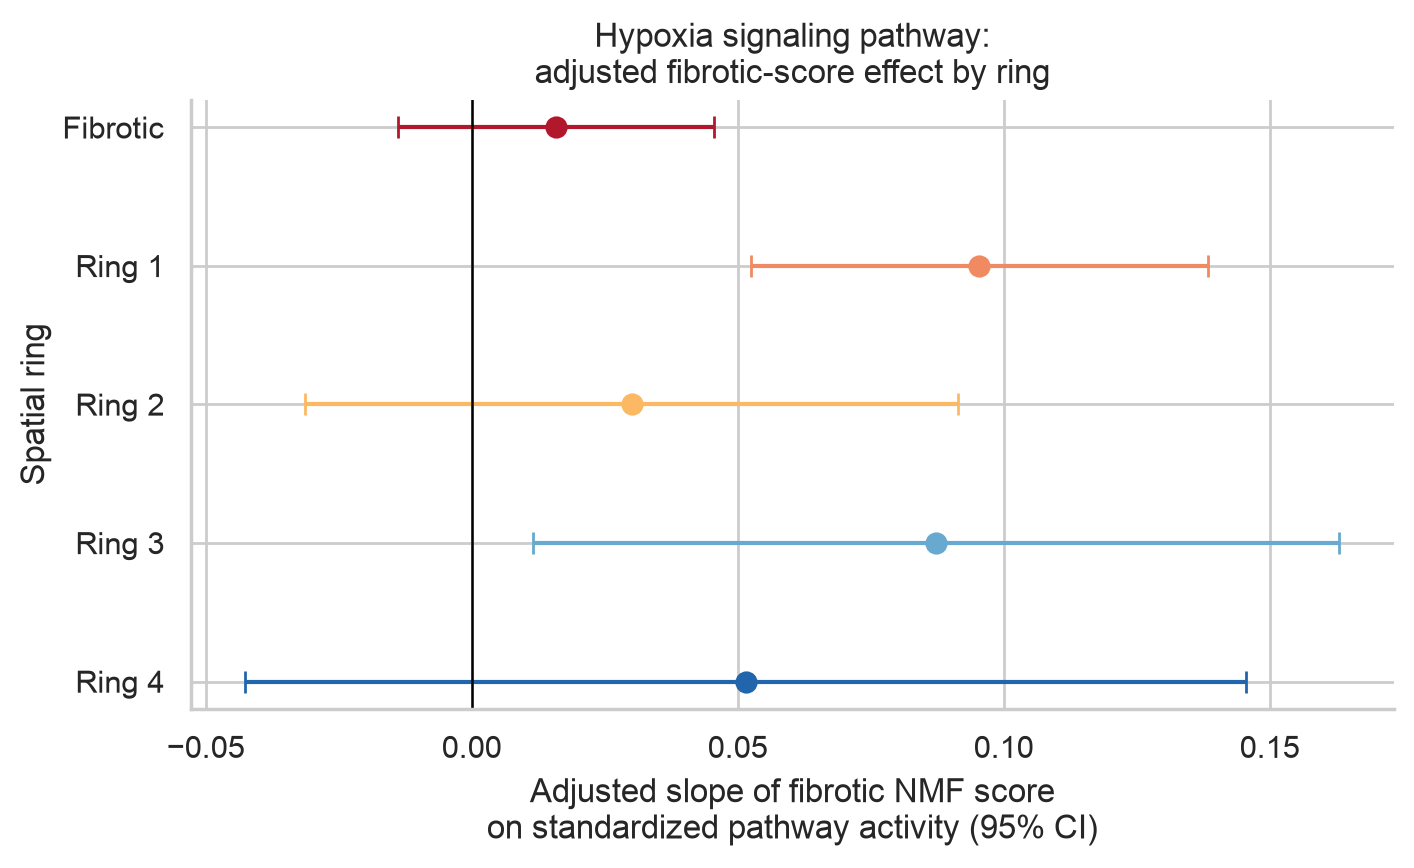

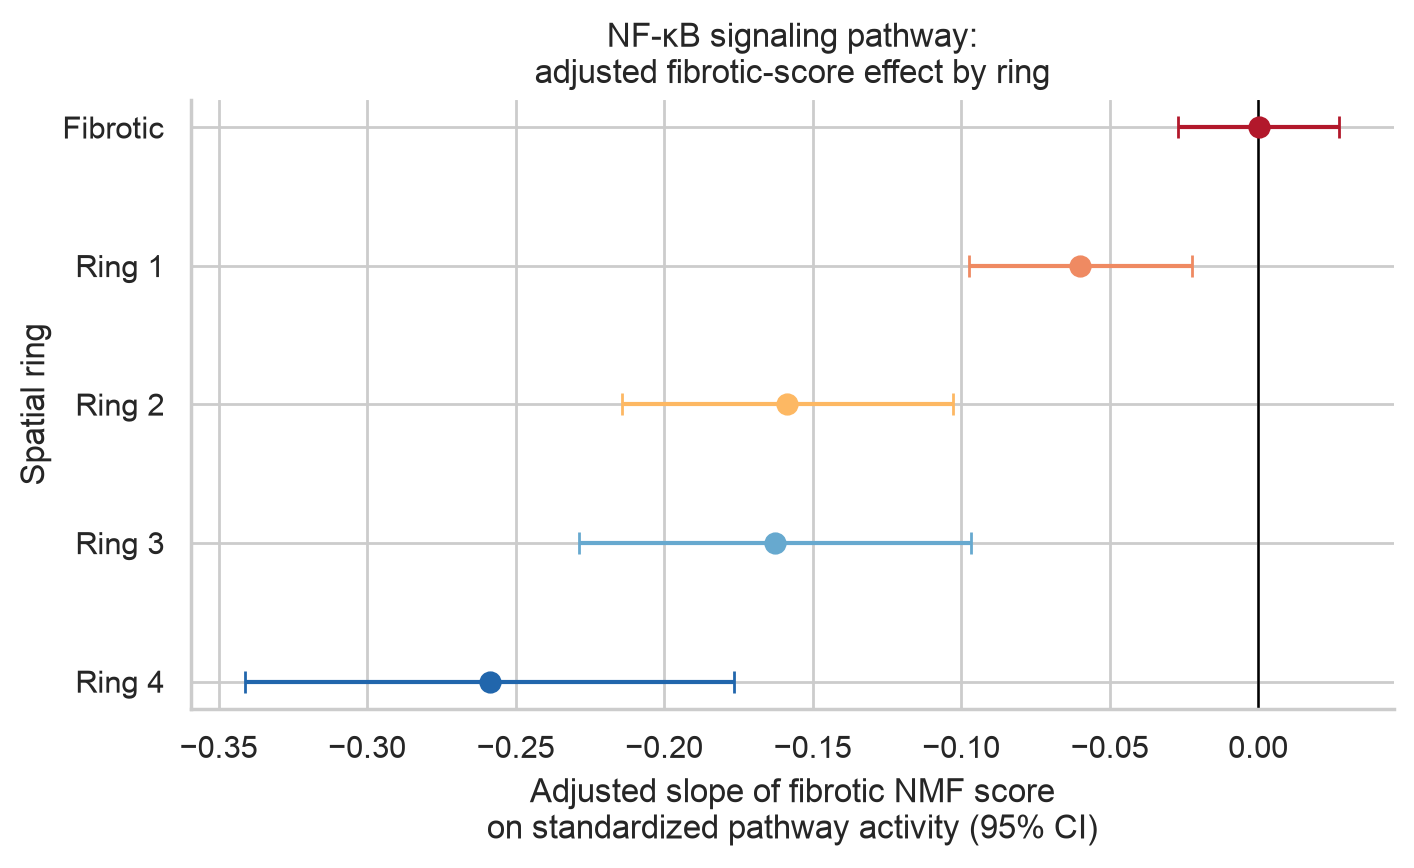

In [16]:
detail_pathways = ["TGFb", "MAPK", "EGFR", "TNFa", "Hypoxia", "NFkB"]

def adjusted_slope_plot(feature):
    plot_data = (
        fibrotic_slopes.query(
            "outcome_type == 'Pathway' and feature == @feature"
        )
        .copy()
        .set_index("ring")
        .reindex(ring_order)
        .reset_index()
    )

    y = np.arange(len(plot_data))
    fig, ax = plt.subplots(figsize=(7.2, 4.5))

    for position, row in plot_data.iterrows():
        color = ring_palette[row["ring"]]
        ax.errorbar(
            row["slope"],
            position,
            xerr=np.array([[
                row["slope"] - row["ci_low"],
                row["ci_high"] - row["slope"],
            ]]).T,
            fmt="o",
            color=color,
            ecolor=color,
            markersize=7,
            capsize=4,
            linewidth=1.5,
        )

    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_yticks(y, plot_data["ring"])
    ax.invert_yaxis()
    ax.set_xlabel(
        "Adjusted slope of fibrotic NMF score\n"
        "on standardized pathway activity (95% CI)"
    )
    ax.set_ylabel("Spatial ring")
    ax.set_title(
        f"{pathway_display_names[feature]}:\n"
        "adjusted fibrotic-score effect by ring"
    )
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

for pathway in detail_pathways:
    adjusted_slope_plot(pathway)

### Reading the adjusted-slope figures

Every point and 95% confidence interval is extracted from the same unified interaction model:

`pathway_activity_z ~ fibrotic_score_z * ring + sample`

`Fibrotic` is the reference ring. Its slope is the main fibrotic-score coefficient; each other slope is the main coefficient plus that ring's interaction coefficient. These are sample-adjusted conditional slopes—not coefficients from separate regressions within individual rings.

Six individual figures are shown: TGF-β signaling pathway, MAPK signaling pathway, EGFR signaling pathway, TNF-α signaling pathway, Hypoxia signaling pathway, and NF-κB signaling pathway. Differences between ring-specific slopes are evaluated by the formal joint interaction test.

## Nine-point ring patterns

To display the interaction pattern directly, spots within each spatial ring are ranked by fibrotic score and divided into nine equal-sized score bins. Measurements are first averaged within each `sample × ring × score bin`, and those sample-level means are then averaged across sections. Each ring therefore contributes nine sample-balanced points.

The colored trend lines below are descriptive fits through these nine aggregated points. They make the pattern easy to see, while the unified interaction model and adjusted-slope confidence-interval figures above remain the formal statistical analysis.

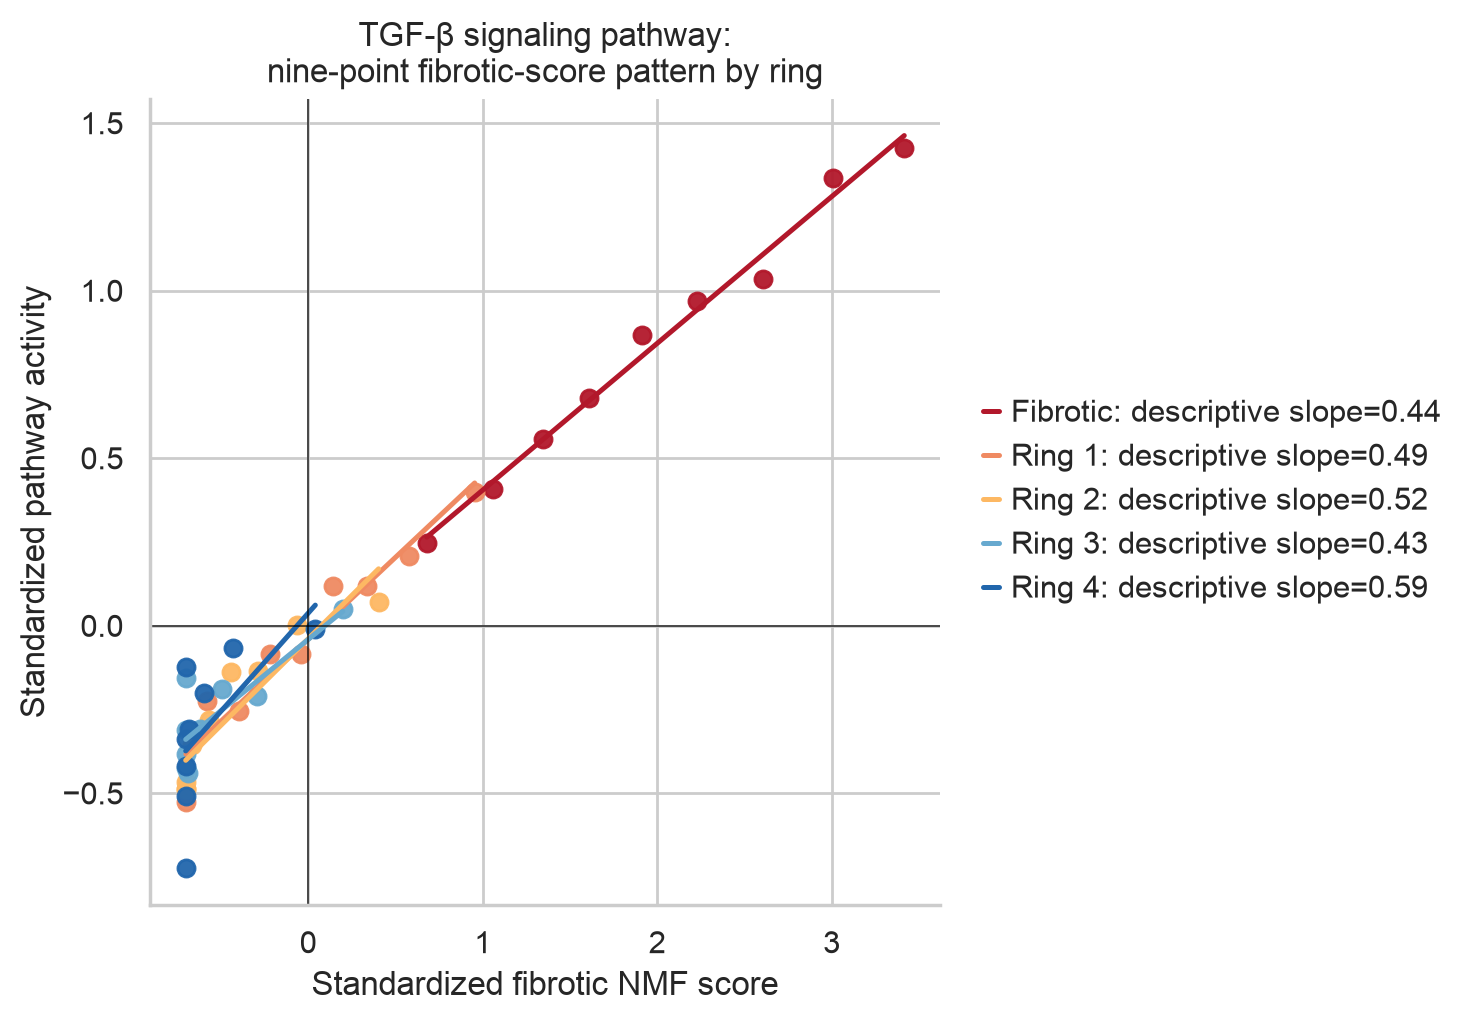

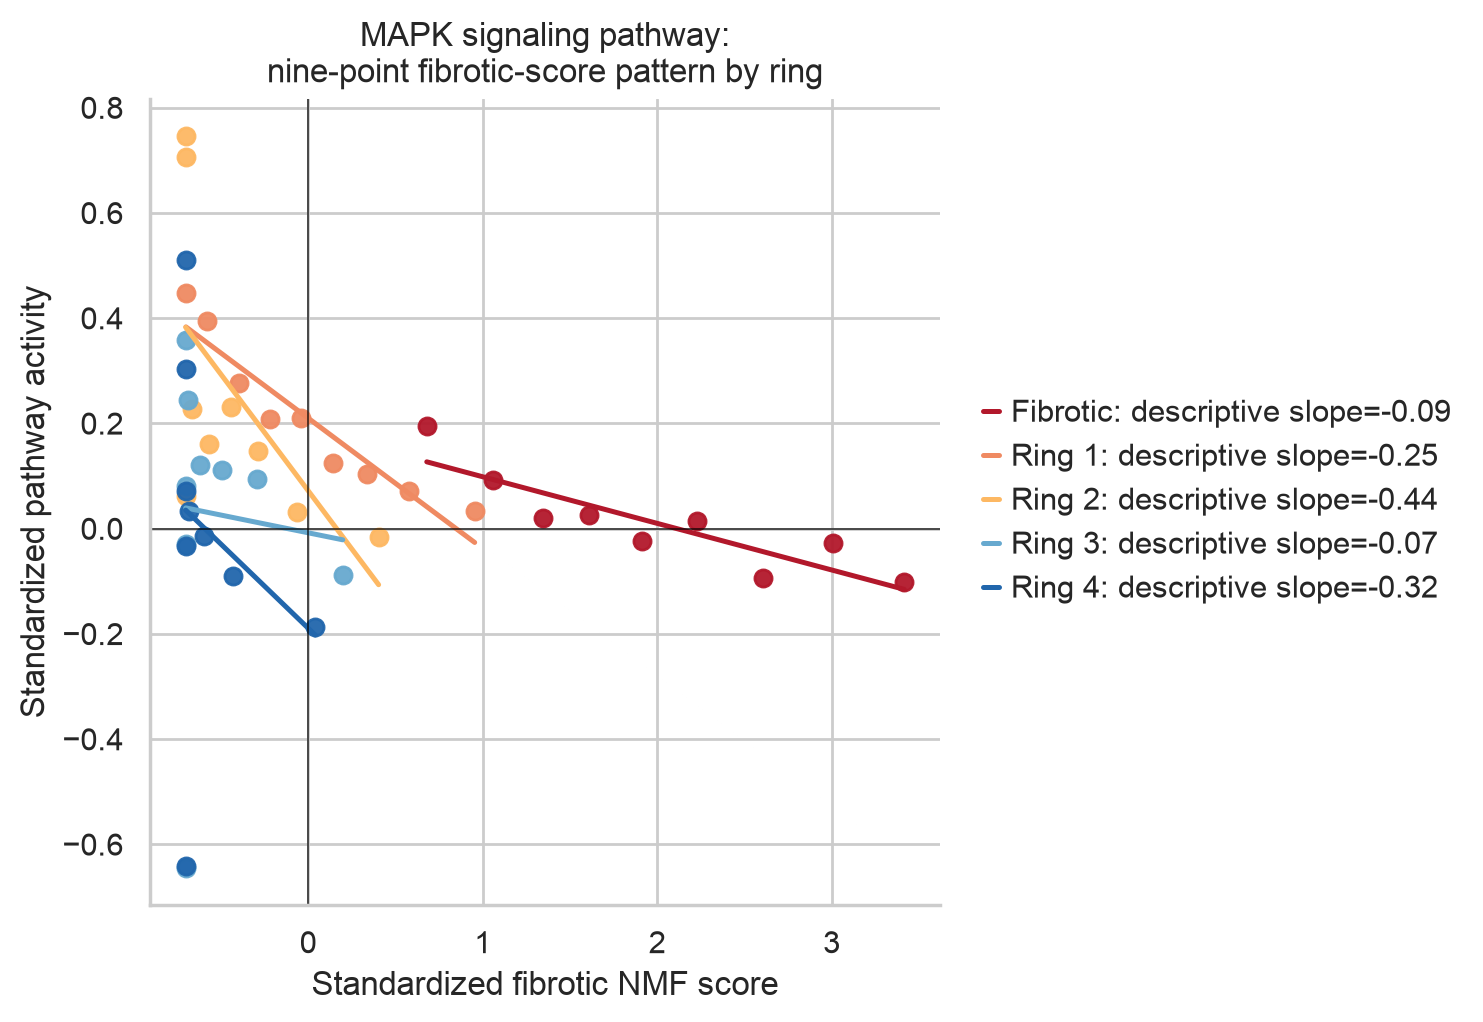

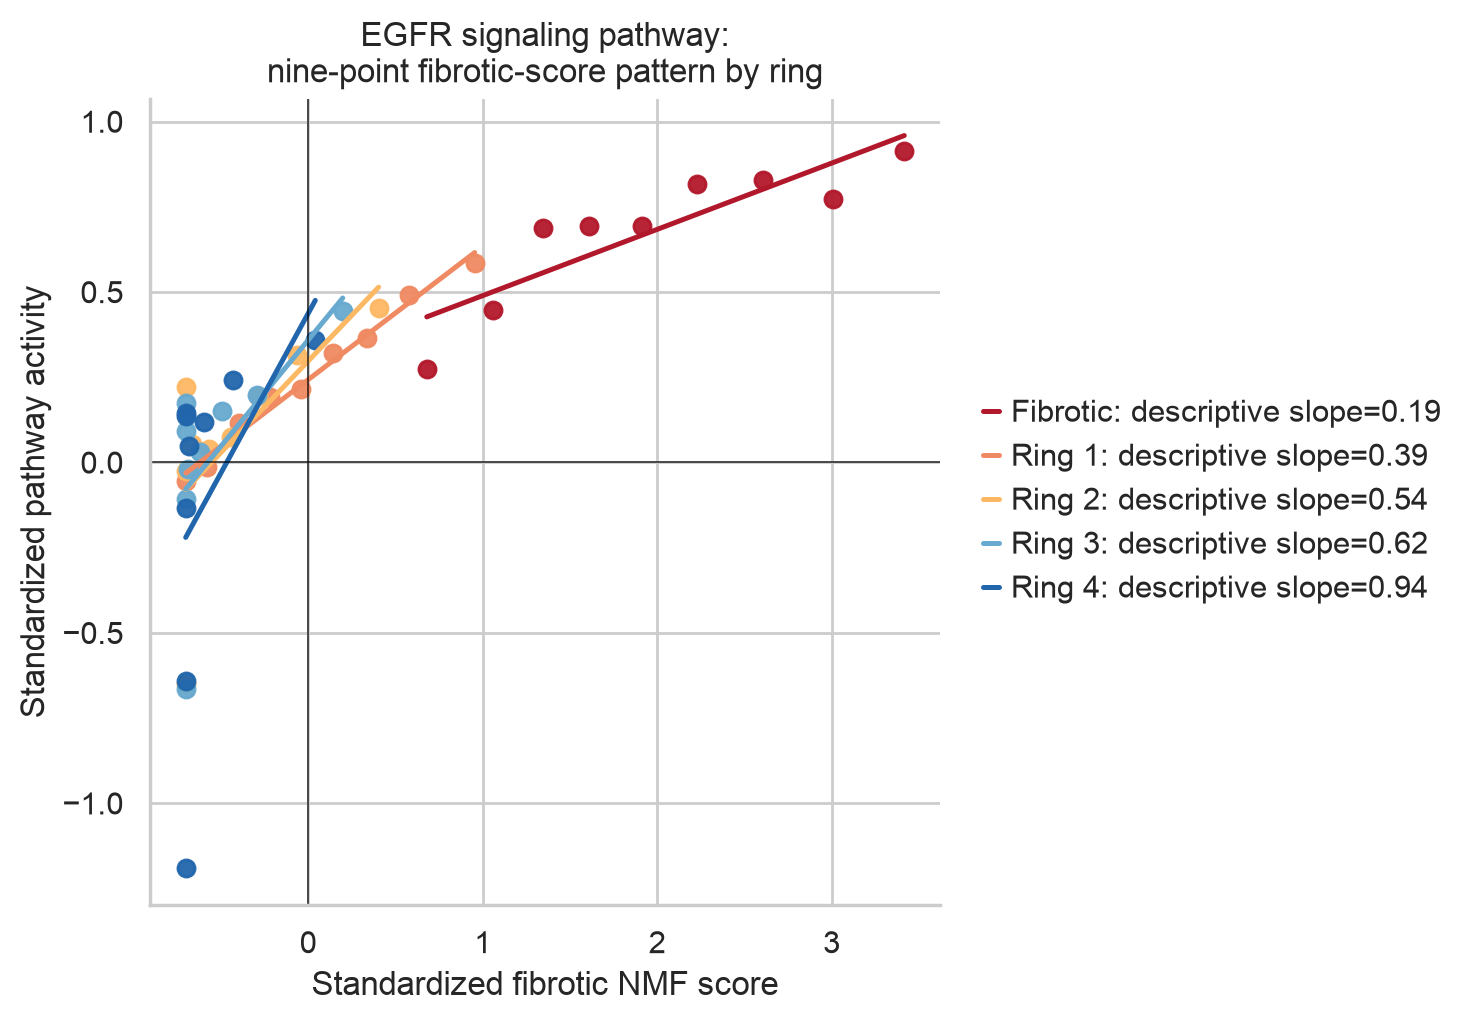

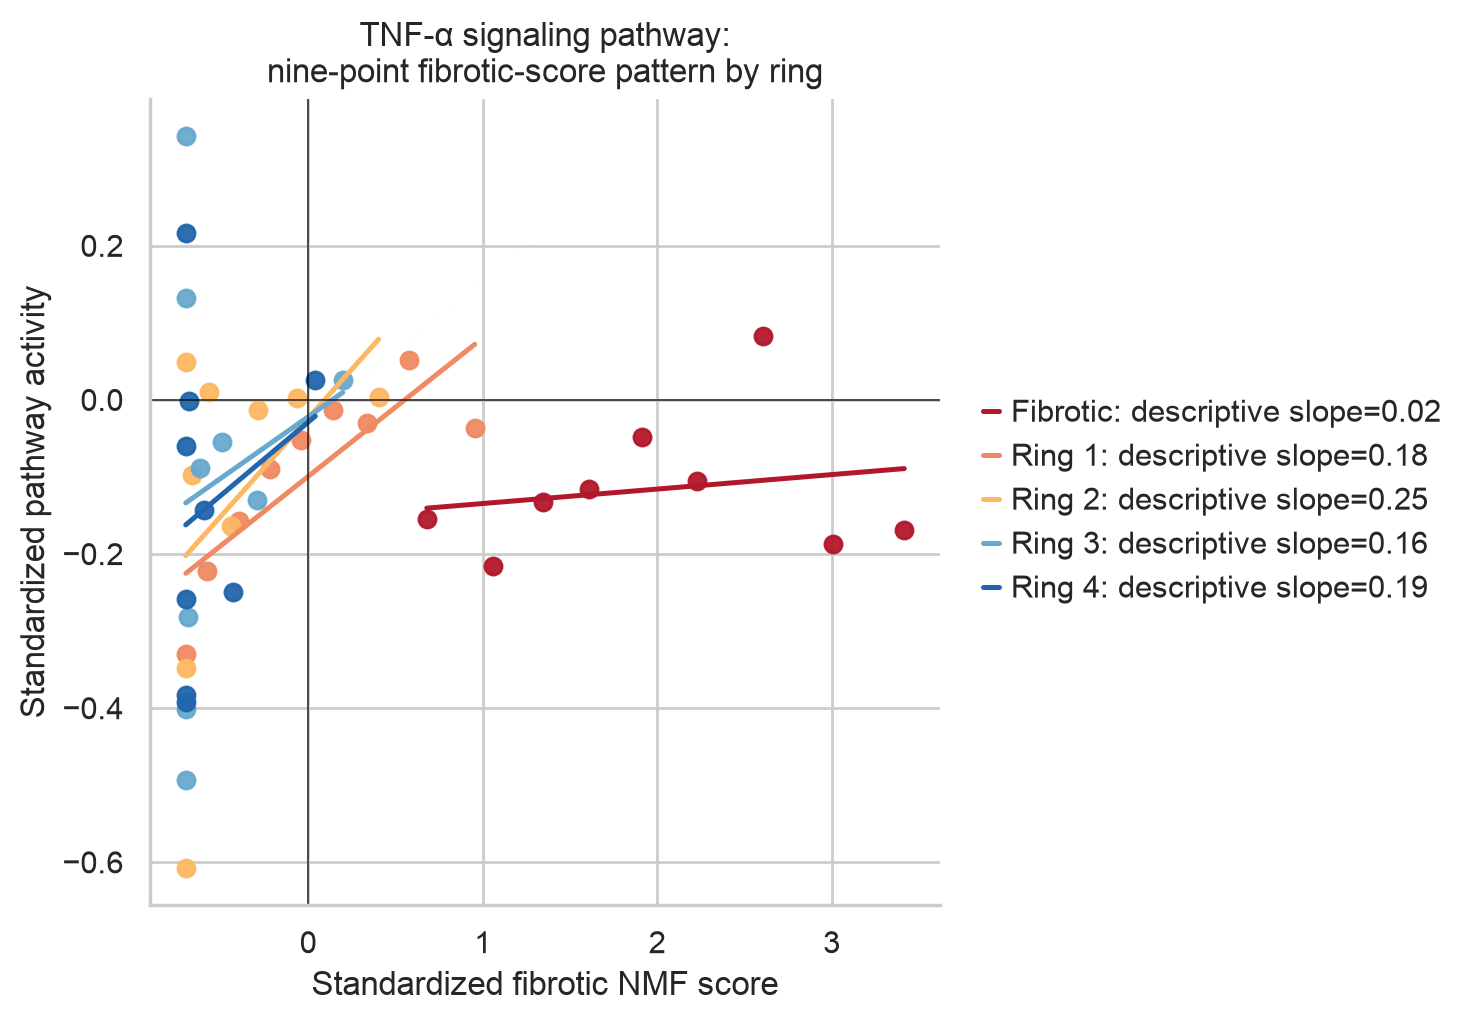

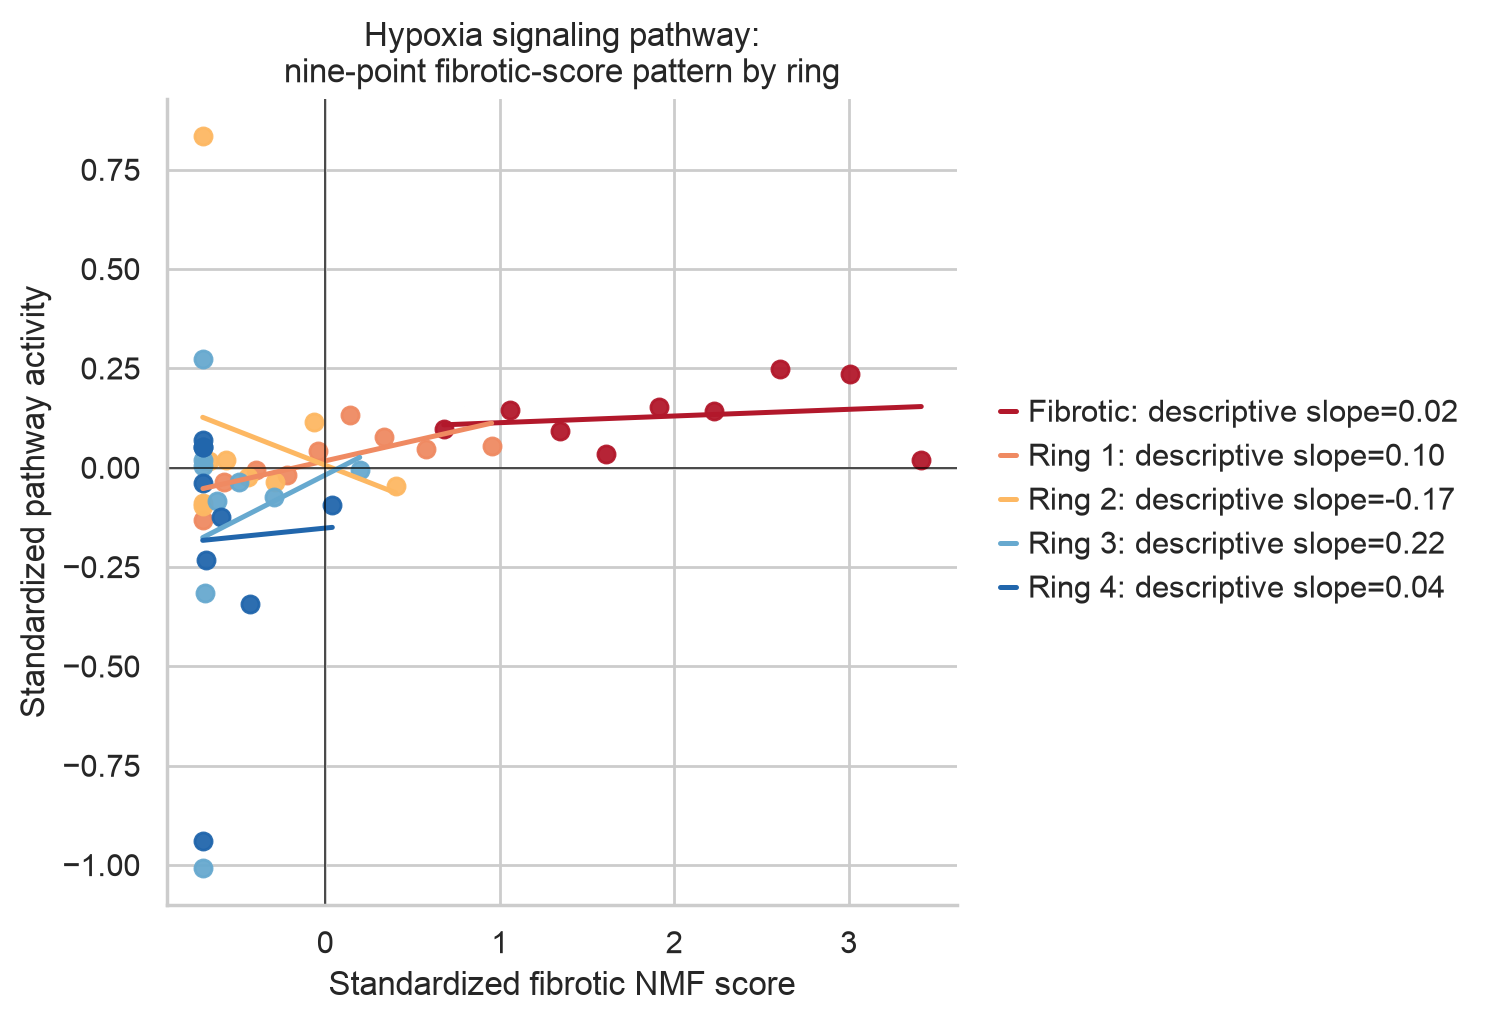

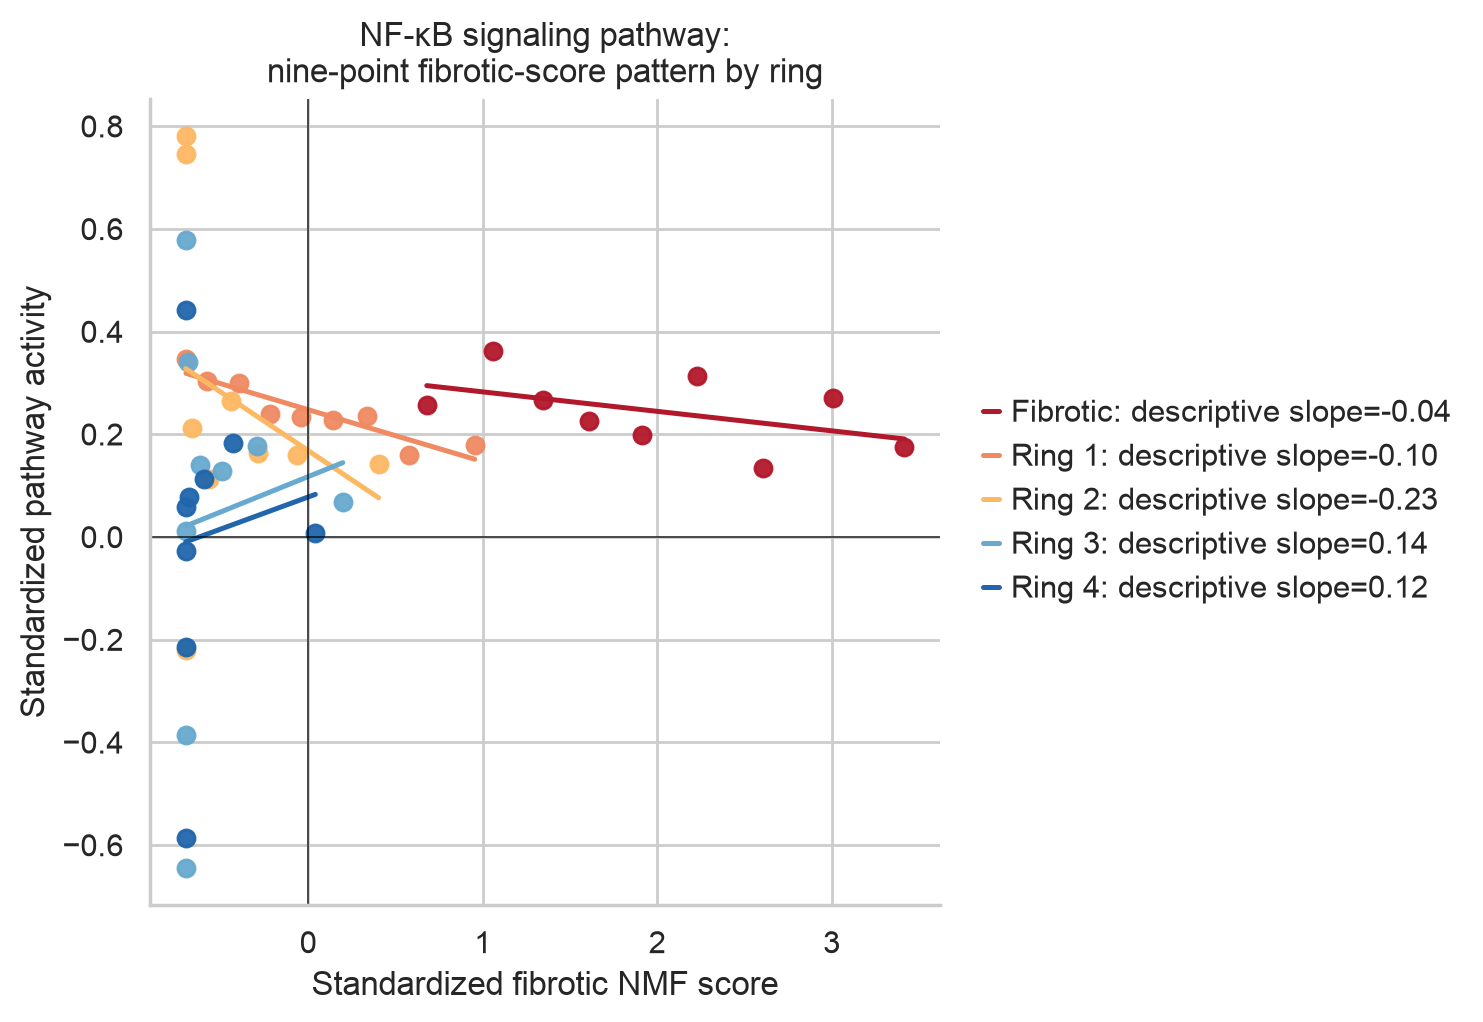

In [17]:
pattern_pathways = ["TGFb", "MAPK", "EGFR", "TNFa", "Hypoxia", "NFkB"]

pattern_base = base[["sample", "ring", "fibrotic_score_z"]].copy()
pattern_base["score_bin"] = (
    pattern_base.groupby("ring", observed=True)["fibrotic_score_z"]
    .transform(
        lambda values: pd.qcut(
            values.rank(method="first"),
            q=9,
            labels=np.arange(1, 10),
        )
    )
    .astype(int)
)

def nine_point_pattern_plot(feature):
    frame = pattern_base.copy()
    frame["activity_z"] = z(outcomes["Pathway"][feature])

    # First average within each section; then give every section equal weight.
    sample_bin_means = (
        frame.groupby(["sample", "ring", "score_bin"], observed=True)
        [["fibrotic_score_z", "activity_z"]]
        .mean()
        .reset_index()
    )
    plot_data = (
        sample_bin_means.groupby(["ring", "score_bin"], observed=True)
        [["fibrotic_score_z", "activity_z"]]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7.6, 5.3))
    for ring in ring_order:
        part = plot_data.loc[plot_data["ring"].eq(ring)].sort_values("fibrotic_score_z")
        color = ring_palette[ring]
        ax.scatter(
            part["fibrotic_score_z"],
            part["activity_z"],
            color=color,
            s=38,
            alpha=0.95,
        )
        slope, intercept = np.polyfit(
            part["fibrotic_score_z"],
            part["activity_z"],
            1,
        )
        x_values = np.linspace(
            part["fibrotic_score_z"].min(),
            part["fibrotic_score_z"].max(),
            60,
        )
        ax.plot(
            x_values,
            intercept + slope * x_values,
            color=color,
            linewidth=1.8,
            label=f"{ring}: descriptive slope={slope:.2f}",
        )

    ax.axhline(0, color="black", linewidth=0.7, alpha=0.65)
    ax.axvline(0, color="black", linewidth=0.7, alpha=0.65)
    ax.set_title(f"{pathway_display_names[feature]}:\nnine-point fibrotic-score pattern by ring")
    ax.set_xlabel("Standardized fibrotic NMF score")
    ax.set_ylabel("Standardized pathway activity")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 0.5), loc="center left")
    sns.despine(ax=ax)
    fig.subplots_adjust(right=0.70)
    plt.show()

for pathway in pattern_pathways:
    nine_point_pattern_plot(pathway)

### How to interpret these pattern plots

Each color represents one spatial ring, and each colored point represents one fibrotic-score bin averaged across the available IPF sections—not one individual sample or spot. Parallel lines indicate relatively stable fibrotic-score coupling across space; visibly different slopes indicate spatially varying coupling.

These descriptive slopes may differ slightly from the adjusted slopes above because the pattern plots operate on nine aggregated points per ring. Statistical claims about interaction should therefore use the unified model; these figures are intended to reveal the biological pattern clearly.

## Molecular landscapes across fibrotic score and ring

For visualization, spots are divided into eight fibrotic-score quantile bins. Within each `sample × score bin × ring`, standardized expression or pathway activity is averaged first; the displayed value is then averaged across samples. This prevents sections with more spots from dominating the color pattern.

Rows run from low to high fibrotic score and columns run from the Fibrotic core through Ring 4. These heatmaps visualize two-dimensional patterns but do not replace the formal interaction tests above.

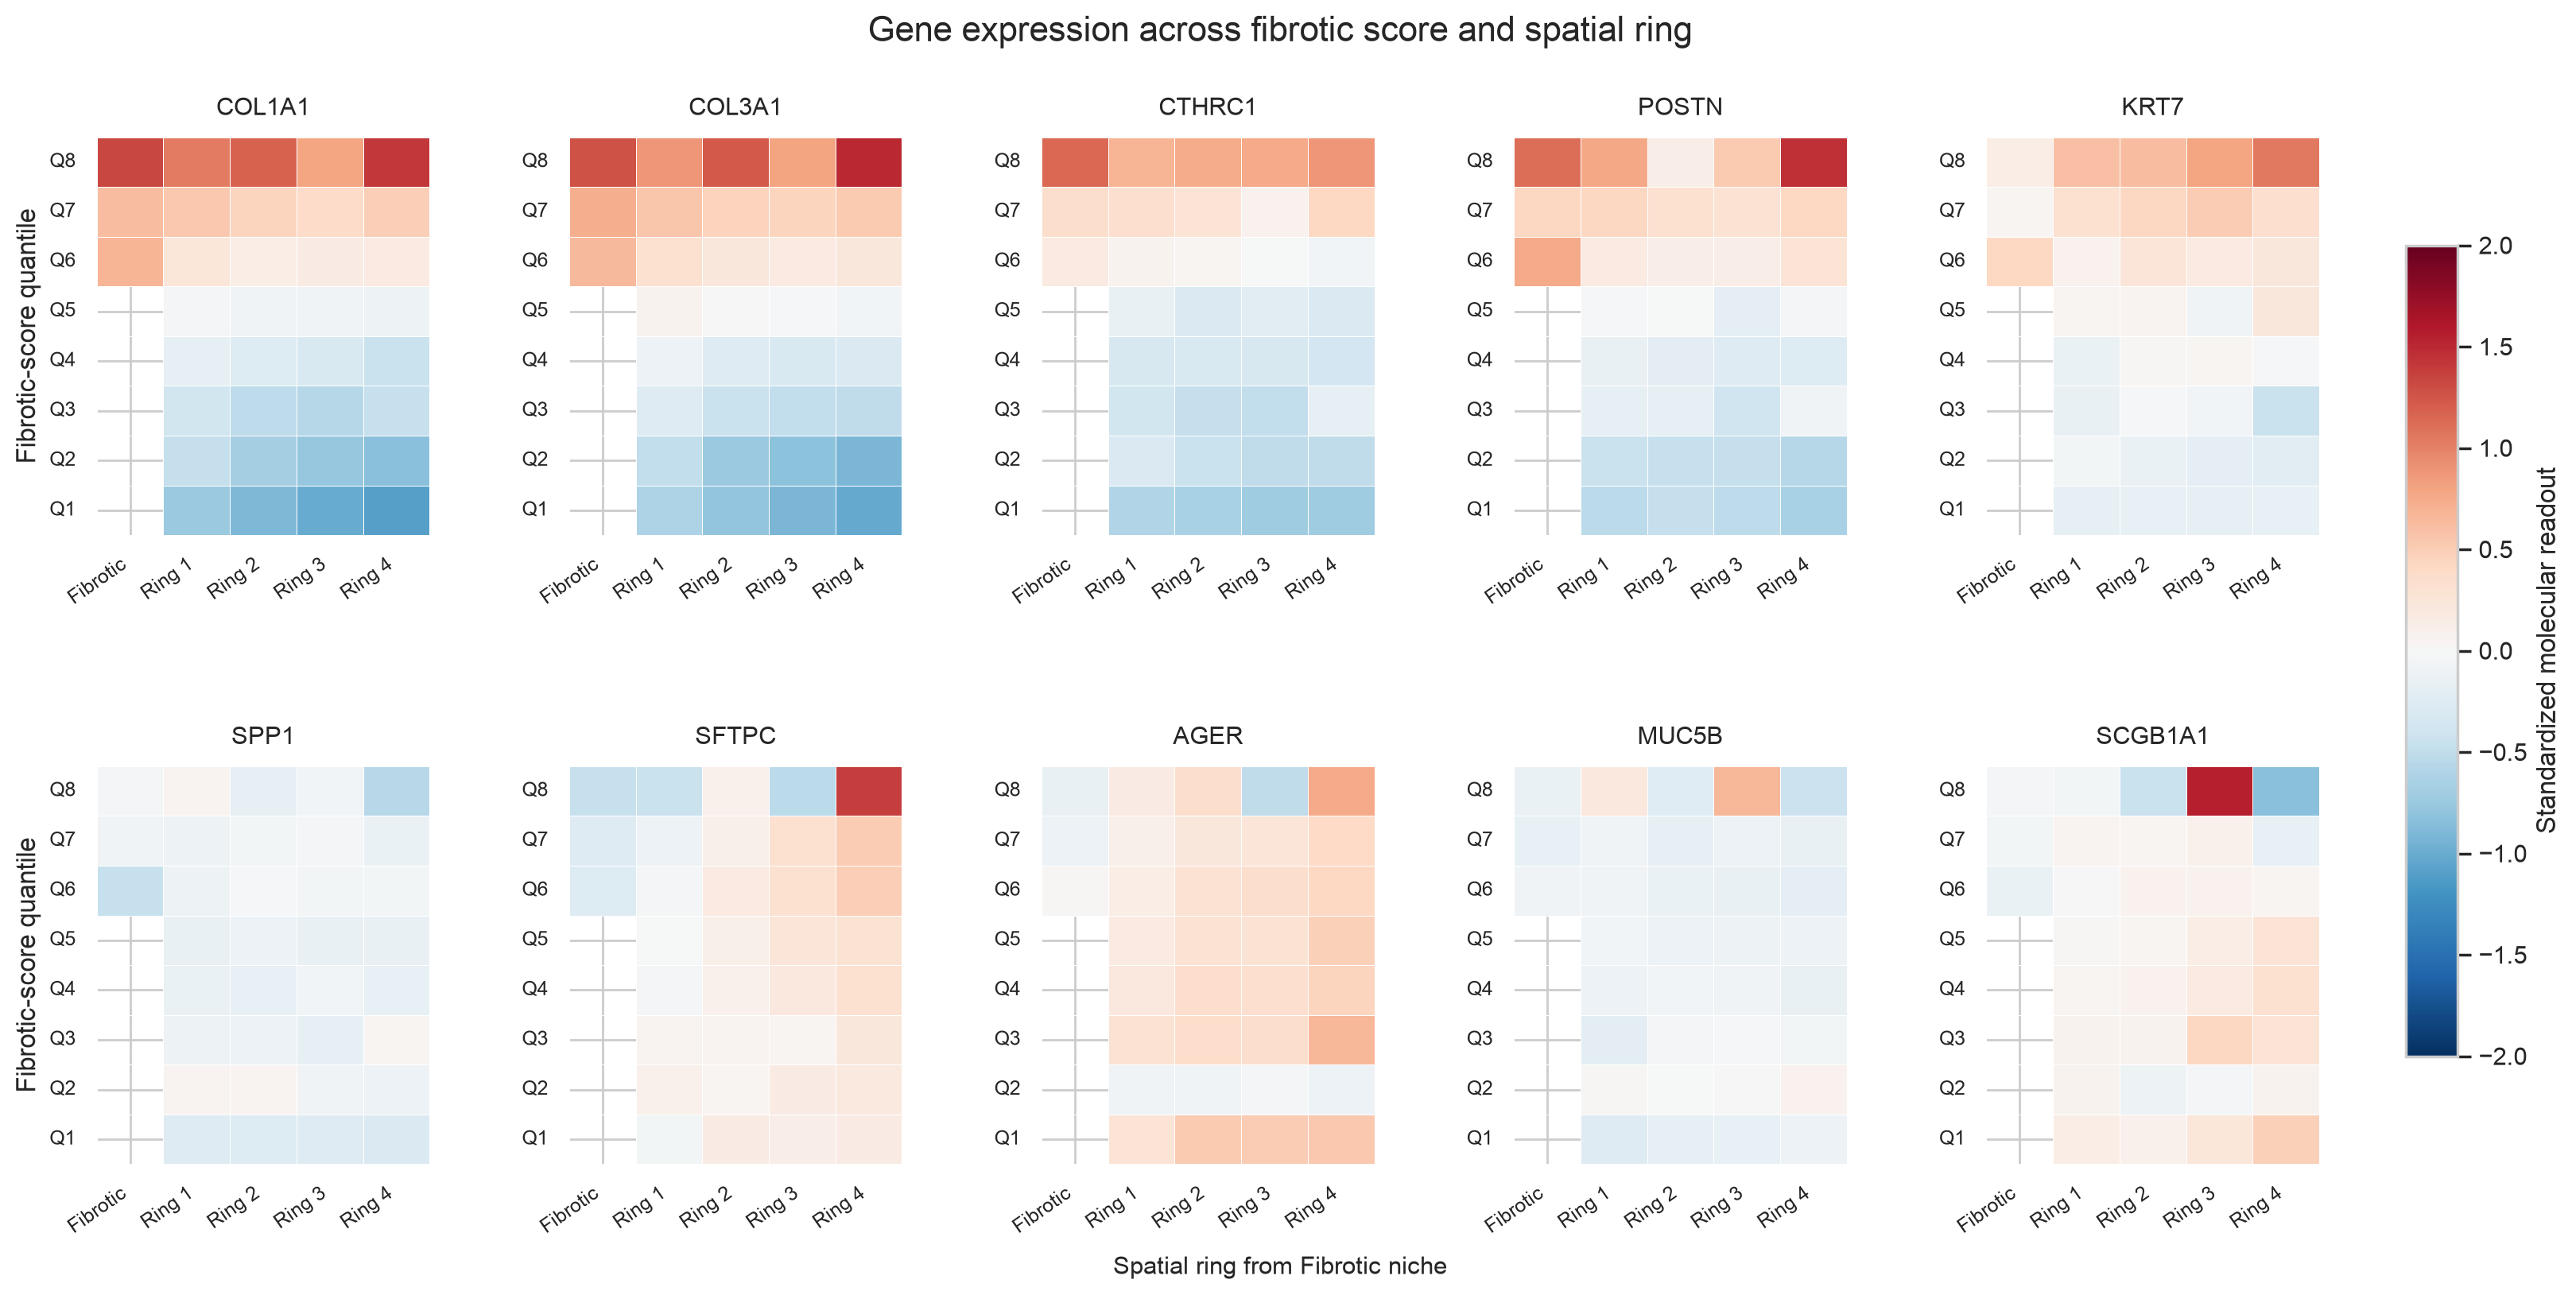

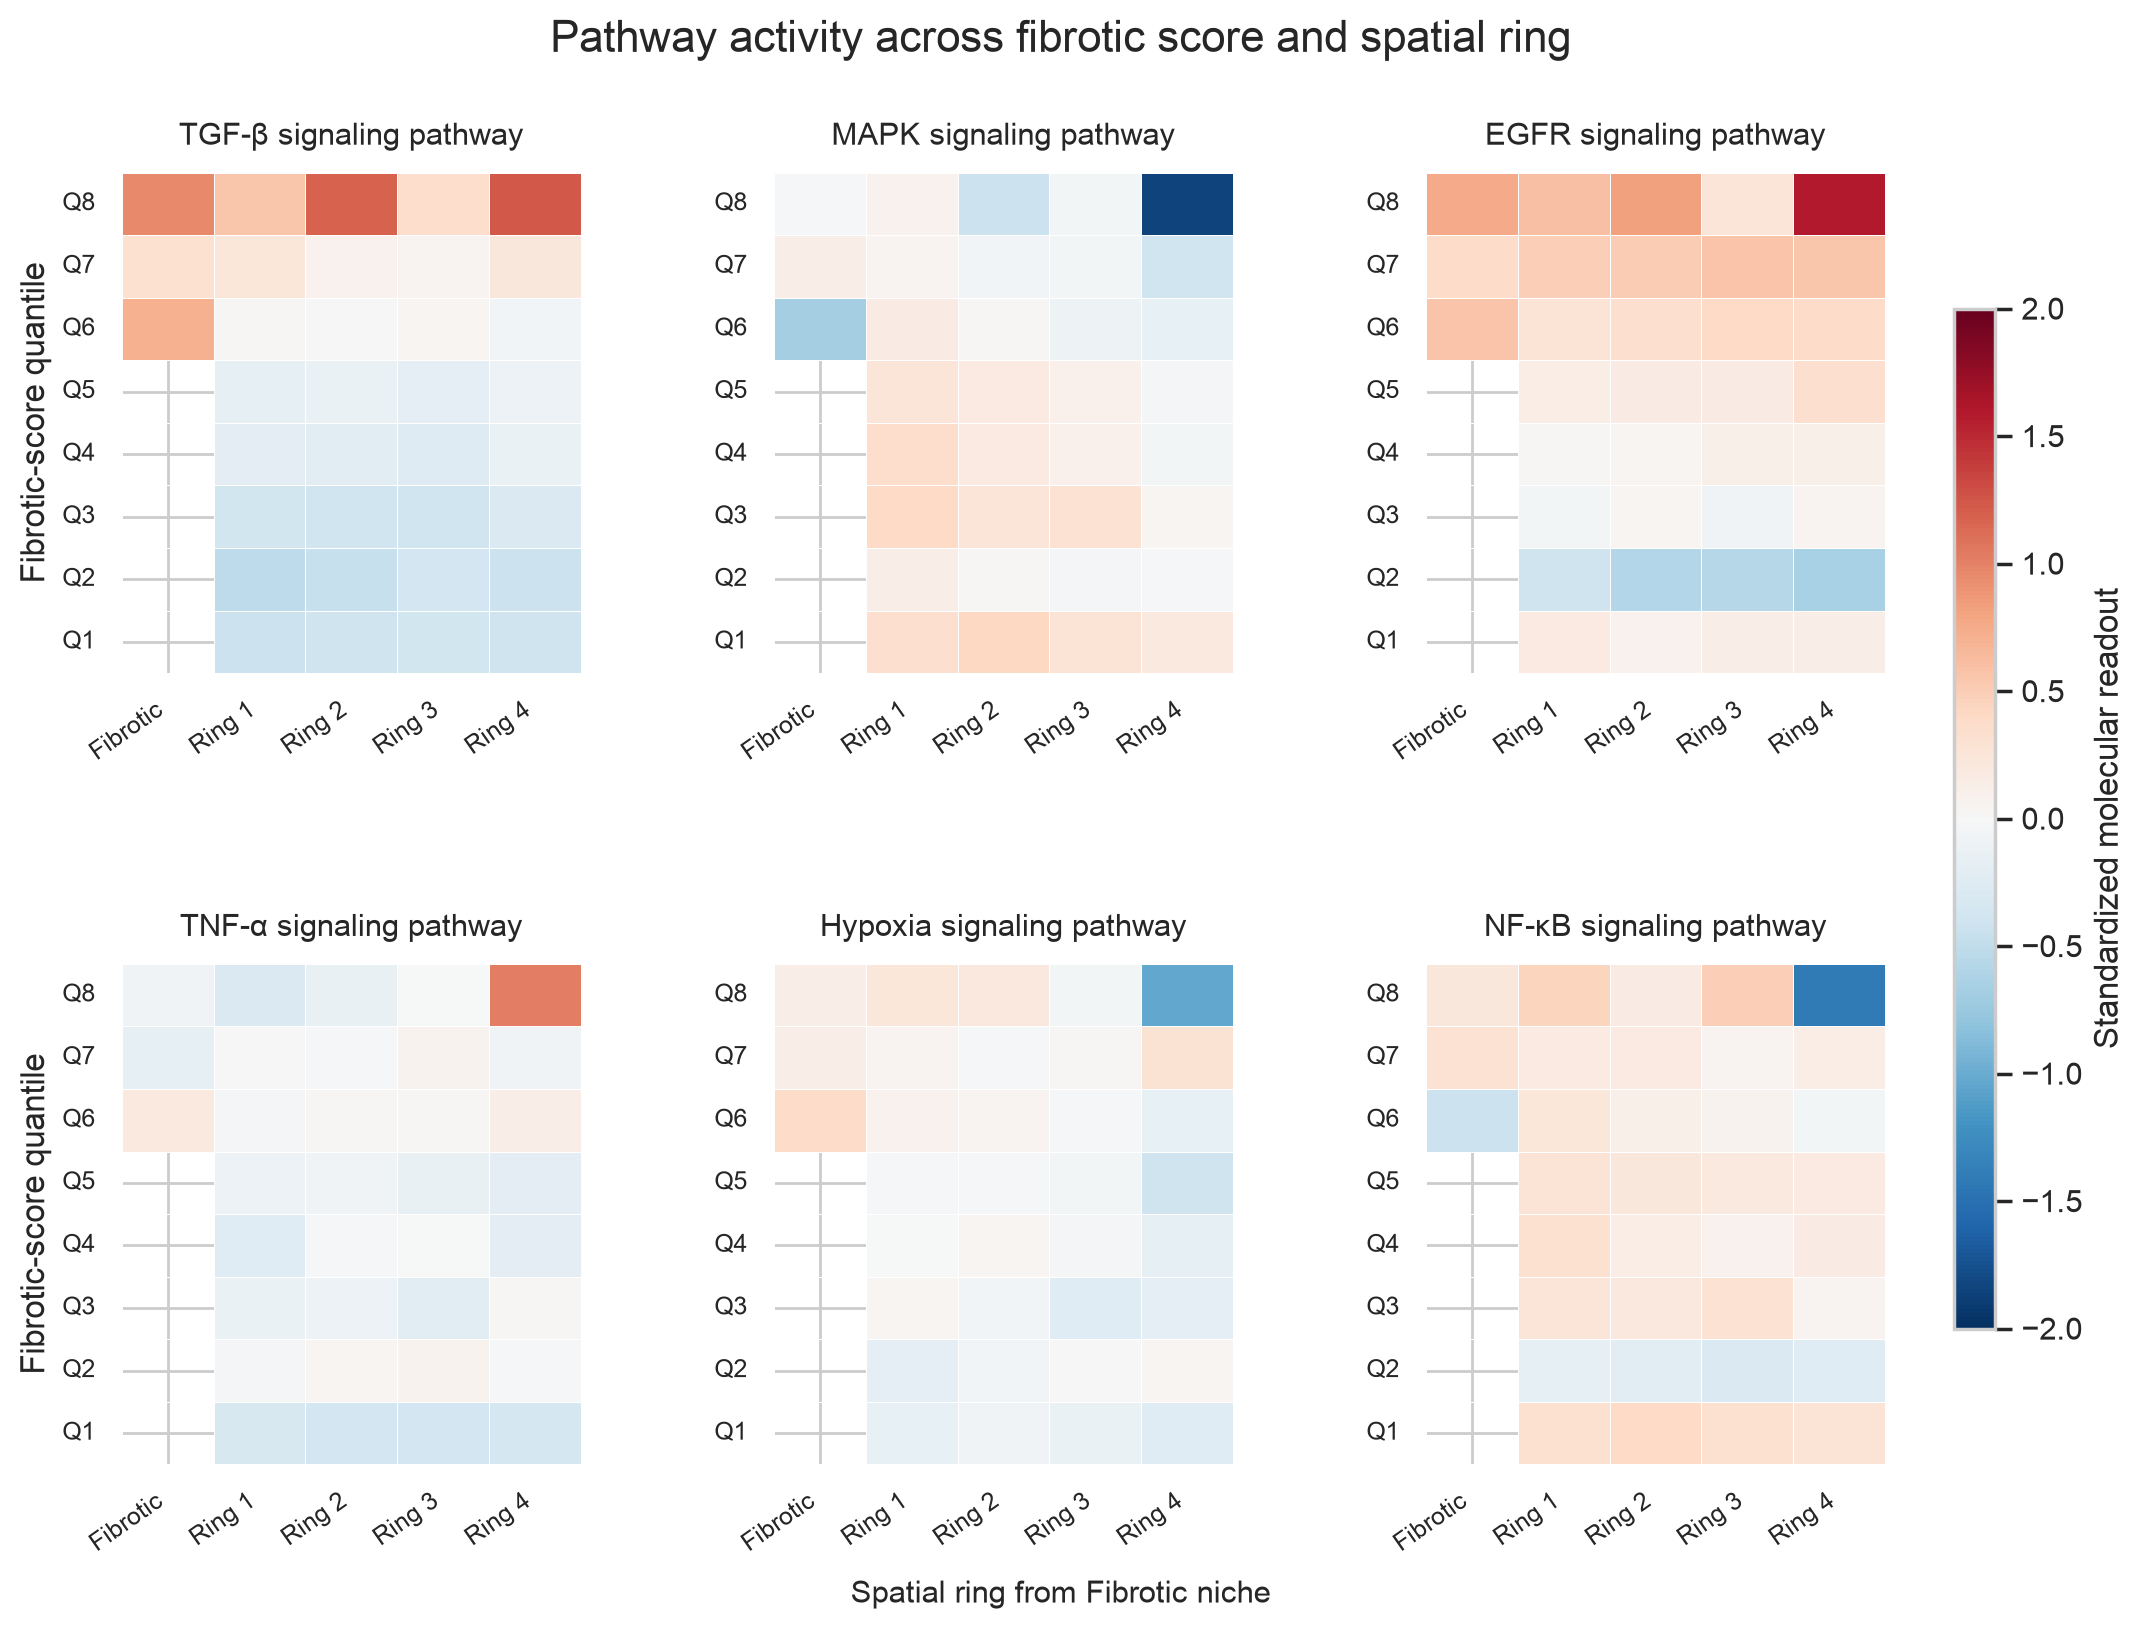

In [18]:
score_bin_order = [f"Q{i}" for i in range(1, 9)]
base["score_bin"] = pd.qcut(
    base["fibrotic_score"].rank(method="first"),
    q=8,
    labels=score_bin_order,
)

def interaction_heatmap_matrix(values):
    frame = base[["sample", "ring", "score_bin"]].copy()
    frame["value_z"] = z(values)
    return (
        frame.groupby(["sample", "score_bin", "ring"], observed=True)["value_z"]
        .mean()
        .groupby(["score_bin", "ring"], observed=True)
        .mean()
        .unstack("ring")
        .reindex(index=score_bin_order[::-1], columns=ring_order)
    )

def heatmap_grid(feature_names, outcome_frame, ncols, title):
    nrows = int(np.ceil(len(feature_names) / ncols))
    width = 3.35 * ncols + 1.4
    height = 3.65 * nrows + 1.2
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, height), squeeze=False)

    for panel_index, (feature, ax) in enumerate(zip(feature_names, axes.flat)):
        matrix = interaction_heatmap_matrix(outcome_frame[feature])
        sns.heatmap(
            matrix,
            cmap="RdBu_r",
            center=0,
            vmin=-2,
            vmax=2,
            cbar=False,
            linewidths=0.25,
            ax=ax,
        )
        panel_title = pathway_display_names.get(feature, feature)
        ax.set_title(panel_title, fontsize=11, pad=10)
        ax.set_xlabel("")
        ax.set_ylabel("Fibrotic-score quantile" if panel_index % ncols == 0 else "")
        ax.tick_params(axis="x", labelrotation=35, labelsize=9, pad=3)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")
        ax.tick_params(axis="y", labelrotation=0, labelsize=9)

    for ax in axes.flat[len(feature_names):]:
        ax.set_visible(False)

    # Reserve separate margins for the shared title, x label, and colorbar.
    fig.subplots_adjust(
        left=0.09,
        right=0.86,
        bottom=0.12,
        top=0.88,
        hspace=0.58,
        wspace=0.42,
    )
    colorbar_ax = fig.add_axes([0.89, 0.20, 0.018, 0.60])
    scalar_map = plt.cm.ScalarMappable(
        cmap="RdBu_r",
        norm=plt.Normalize(-2, 2),
    )
    fig.colorbar(
        scalar_map,
        cax=colorbar_ax,
        label="Standardized molecular readout",
    )
    fig.suptitle(title, fontsize=16, y=0.97)
    fig.supxlabel("Spatial ring from Fibrotic niche", fontsize=11, y=0.035)
    plt.show()

heatmap_grid(genes, outcomes["Gene"], 5, "Gene expression across fibrotic score and spatial ring")
heatmap_grid(heatmap_pathways, outcomes["Pathway"], 3, "Pathway activity across fibrotic score and spatial ring")

### Biological interpretation

- `COL1A1`, `COL3A1`, `CTHRC1`, and `POSTN` are expected to show their strongest standardized expression in high-fibrotic-score strata, particularly within or near the Fibrotic niche. A consistent decline across columns indicates spatial attenuation away from the niche.
- `SFTPC` and `AGER` represent alveolar epithelial identity and provide a contrast to the matrix-remodeling program. Their patterns help identify regions in which alveolar differentiation is relatively preserved or lost.
- The six pathway panels represent complementary biological programs: profibrotic TGF-β signaling pathway; growth and tissue-remodeling MAPK signaling pathway; epithelial growth/remodeling EGFR signaling pathway; inflammatory TNF-α signaling pathway; metabolic-stress Hypoxia signaling pathway; and inflammatory NF-κB signaling pathway. Non-parallel color gradients across fibrotic-score quantiles and spatial rings provide visual evidence of possible interaction.

Colors are standardized separately for each molecular readout, so comparisons should be made within a panel rather than between different genes or pathways.

## Summary

- Notebook 04 estimated average additive fibrotic-score and distance effects.
- Notebook 05 tests whether fibrotic-score associations change across discrete rings.
- Joint interaction FDR is the primary evidence; ring-specific slopes describe the pattern.
- The two-dimensional heatmaps show the observed molecular landscape across fibrotic-score quantiles and rings.
- Cell-type-composition interactions are not included.
- Results require validation in additional tissue sections because only five IPF sections are represented.